# **Video Action Recognition using LRCN on UCF50**

This notebook implements a Long-term Recurrent Convolutional Network (LRCN) for video classification. The model combines a pretrained convolutional neural network (CNN) backbone for spatial feature extraction with a bidirectional LSTM network and temporal attention mechanism to capture temporal dependencies across video frames.

The pipeline includes dataset loading, video frame preprocessing, train/validation/test splitting, data augmentation, model training, validation, and final evaluation. The model is trained using supervised learning with cross-entropy loss and Adam optimizer, and performance is evaluated using accuracy, classification reports, and confusion matrices.

The implementation is organized into modular components for reproducibility:
- Dataset preparation and frame processing
- CNN feature extraction using ResNet
- Temporal sequence modeling using BiLSTM with attention
- Model training and checkpoint saving
- Test evaluation and performance analysis

Weights & Biases (W&B) logging is used to track training and validation metrics, including loss, accuracy, learning rate, and evaluation results.

## **1. Imports and Setup**

In [1]:
%cd /content

!rm -rf "/content/video_action"

!git clone https://github.com/rdey6/video_action.git
%cd video_action

!pip install -r requirements.txt
!pip install wandb

!apt-get install unrar

import wandb

/content
Cloning into 'video_action'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (48/48), done.
remote: Total 70 (delta 42), reused 50 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (70/70), 29.31 KiB | 14.66 MiB/s, done.
Resolving deltas: 100% (42/42), done.
/content/video_action
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.


## **2. Weights & Biases (W&B) Setup**

In [2]:
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rahuldey-mle (rahuldey-mle-johns-hopkins-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## **3. Download UCF50 dataset**

In [3]:
!rm -rf "/content/UCF50"

!wget --no-check-certificate -P /content/UCF50 https://www.crcv.ucf.edu/data/UCF50.rar
!unrar x /content//UCF50/UCF50.rar /content/UCF50

Streaming output truncated to the last 5000 lines.
Extracting  /content/UCF50/UCF50/HorseRace/v_HorseRace_g16_c03.avi        23%  OK 
Extracting  /content/UCF50/UCF50/HorseRace/v_HorseRace_g16_c04.avi        23%  OK 
Extracting  /content/UCF50/UCF50/HorseRace/v_HorseRace_g16_c05.avi        23%  OK 
Extracting  /content/UCF50/UCF50/HorseRace/v_HorseRace_g17_c01.avi        23%  OK 
Extracting  /content/UCF50/UCF50/HorseRace/v_HorseRace_g17_c02.avi        23%  OK 
Extracting  /content/UCF50/UCF50/HorseRace/v_HorseRace_g17_c03.avi        23%  OK 
Extracting  /content/UCF50/UCF50/HorseRace/v_HorseRace_g17_c04.avi        23%  OK 
Extracting  /content/UCF50/UCF50/HorseRace/v_HorseRace_g17_c05.avi        23%  OK 
Extracting  /content/UCF50/UCF50/HorseRace/v_HorseRace_g18_c01.avi        23%  OK 
Extracting  /content/UCF50/UCF50/HorseRace/v_HorseRace_g18_c02.avi        23%  OK 
Extracting  /content/UCF50/UC

## **4. Training**

In [4]:
%cd src

/content/video_action/src


In [5]:
!python run.py \
    --frame_dir "/content/UCF50/UCF50" \
    --cnn_backbone resnet50 \
    --rnn_hidden_size 256 \
    --rnn_n_layers 2 \
    --train_size 0.75 \
    --test_size 0.15 \
    --model_type lrcn \
    --n_classes 50 \
    --fr_per_vid 16 \
    --batch_size 32 \
    --mode 'train' \
    --best_dir '/content/video_action_best_model'

Streaming output truncated to the last 5000 lines.
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
processing
pro

## **5. Training and Validation Curves from W&B**

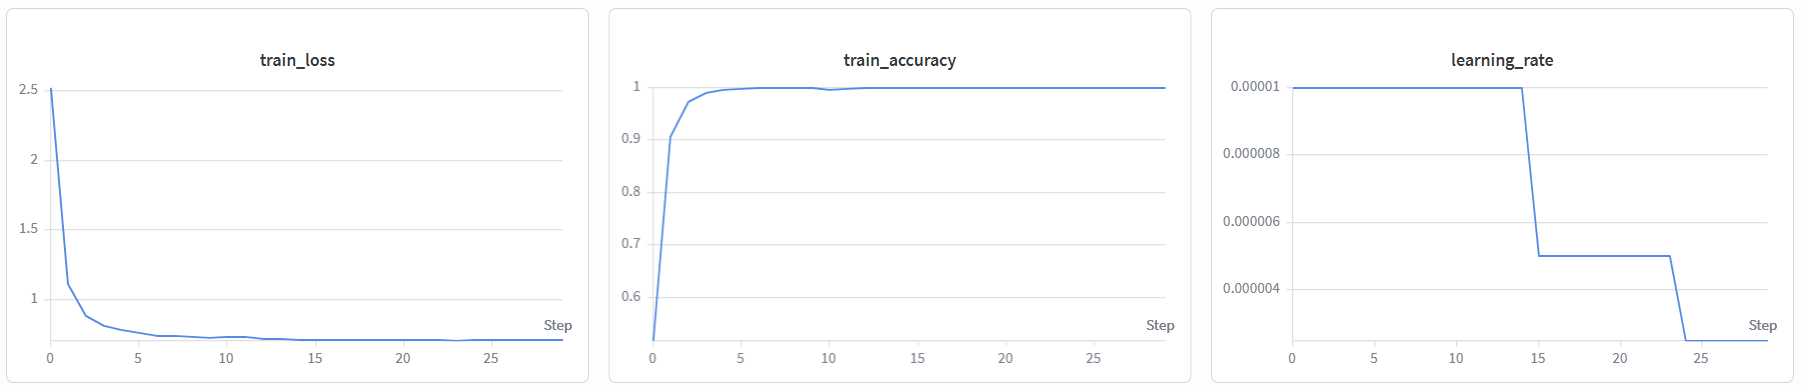

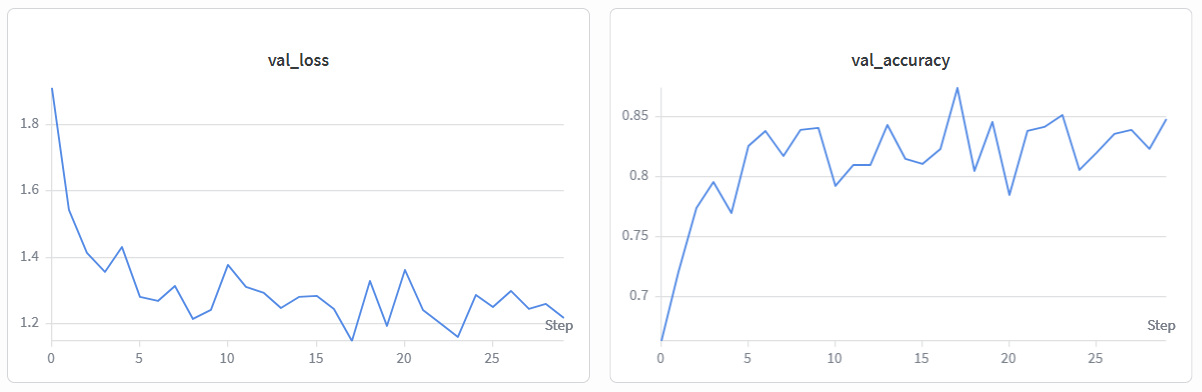

## **6. Project Folder Backup**

In [6]:
!cp -r /content/video_action /content/drive/MyDrive/

## **7. Best Model Checkpoint Backup**

In [7]:
!cp -r /content/video_action_best_model/best_model_wts.pt /content/drive/MyDrive/model/video_action_best_model

## **8. Evaluation**

In [8]:
!python run.py \
    --ckpt /content/drive/MyDrive/model/video_action_best_model/best_model_wts.pt \
    --cnn_backbone resnet50 \
    --model_type lrcn \
    --rnn_hidden_size 256 \
    --rnn_n_layers 2 \
    --n_classes 50 \
    --batch_size 32 \
    --mode eval \
    --frame_dir "/content/UCF50/UCF50"

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: rahuldey-mle (rahuldey-mle-johns-hopkins-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using an existing wandb-core service via WANDB_SERVICE.
wandb: ⢿ setting up run fd4o8unq (0.0s)
wandb: ⣻ setting up run fd4o8unq (

## **9.Classification Report**

| Class | Precision | Recall | F1-Score | Support |
|-------|----------:|-------:|---------:|--------:|
| BaseballPitch | 1.000 | 0.938 | 0.968 | 16 |
| Basketball | 0.800 | 0.750 | 0.774 | 16 |
| BenchPress | 0.864 | 1.000 | 0.927 | 19 |
| Biking | 0.875 | 1.000 | 0.933 | 14 |
| Billiards | 1.000 | 1.000 | 1.000 | 19 |
| BreastStroke | 1.000 | 0.917 | 0.957 | 12 |
| CleanAndJerk | 0.593 | 1.000 | 0.744 | 16 |
| Diving | 0.783 | 1.000 | 0.878 | 18 |
| Drumming | 0.900 | 1.000 | 0.947 | 18 |
| Fencing | 1.000 | 0.714 | 0.833 | 14 |
| GolfSwing | 0.917 | 0.611 | 0.733 | 18 |
| HighJump | 0.909 | 0.667 | 0.769 | 15 |
| HorseRace | 0.762 | 1.000 | 0.865 | 16 |
| HorseRiding | 1.000 | 1.000 | 1.000 | 23 |
| HulaHoop | 0.429 | 0.214 | 0.286 | 14 |
| JavelinThrow | 0.550 | 0.688 | 0.611 | 16 |
| JugglingBalls | 0.783 | 1.000 | 0.878 | 18 |
| JumpRope | 0.533 | 0.533 | 0.533 | 15 |
| JumpingJack | 0.444 | 0.333 | 0.381 | 12 |
| Kayaking | 0.875 | 0.933 | 0.903 | 15 |
| Lunges | 0.650 | 0.650 | 0.650 | 20 |
| MilitaryParade | 1.000 | 1.000 | 1.000 | 14 |
| Mixing | 0.857 | 1.000 | 0.923 | 24 |
| Nunchucks | 0.000 | 0.000 | 0.000 | 23 |
| PizzaTossing | 0.692 | 0.692 | 0.692 | 13 |
| PlayingGuitar | 0.840 | 1.000 | 0.913 | 21 |
| PlayingPiano | 0.923 | 1.000 | 0.960 | 12 |
| PlayingTabla | 1.000 | 0.765 | 0.867 | 17 |
| PlayingViolin | 0.706 | 1.000 | 0.828 | 12 |
| PoleVault | 0.792 | 0.950 | 0.864 | 20 |
| PommelHorse | 1.000 | 1.000 | 1.000 | 12 |
| PullUps | 0.938 | 0.750 | 0.833 | 20 |
| Punch | 1.000 | 1.000 | 1.000 | 18 |
| PushUps | 0.889 | 0.667 | 0.762 | 12 |
| RockClimbingIndoor | 1.000 | 1.000 | 1.000 | 16 |
| RopeClimbing | 0.474 | 0.692 | 0.562 | 13 |
| Rowing | 0.950 | 0.950 | 0.950 | 20 |
| SalsaSpin | 1.000 | 0.778 | 0.875 | 18 |
| SkateBoarding | 1.000 | 0.692 | 0.818 | 13 |
| Skiing | 1.000 | 1.000 | 1.000 | 16 |
| Skijet | 1.000 | 1.000 | 1.000 | 12 |
| SoccerJuggling | 1.000 | 0.550 | 0.710 | 20 |
| Swing | 0.882 | 1.000 | 0.938 | 15 |
| TaiChi | 0.500 | 0.833 | 0.625 | 12 |
| TennisSwing | 0.778 | 1.000 | 0.875 | 21 |
| ThrowDiscus | 0.909 | 0.667 | 0.769 | 15 |
| TrampolineJumping | 0.824 | 1.000 | 0.903 | 14 |
| VolleyballSpiking | 1.000 | 1.000 | 1.000 | 14 |
| WalkingWithDog | 0.909 | 0.714 | 0.800 | 14 |
| YoYo | 0.941 | 1.000 | 0.970 | 16 |
| **Accuracy** |  |  | **0.834** | **811** |
| **Macro Avg** | **0.829** | **0.833** | **0.820** | **811** |
| **Weighted Avg** | **0.828** | **0.834** | **0.820** | **811** |

## **Conclusion**

In this notebook, an enhanced LRCN (Long-term Recurrent Convolutional Network) model was implemented for video action recognition. The model combines a ResNet-based CNN backbone for extracting spatial features from individual video frames with a bidirectional LSTM network to capture temporal dependencies across frame sequences. A multi-head self-attention mechanism was incorporated to refine temporal representations by emphasizing the most informative features across time steps before classification. The proposed approach achieved an accuracy of 83.35% on the video action recognition task, demonstrating the effectiveness of combining spatial feature extraction, bidirectional temporal modeling, and attention-based feature refinement. This enhanced LRCN provides a strong framework for video understanding tasks, while future improvements could explore more advanced architectures such as 3D CNNs, video transformers, or larger-scale pretrained video models to further improve recognition performance.

In [6]:
! pynblint UCF50_VideoActionRecognition.ipynb



********************************** PYNBLINT ***********************************

NOTEBOOK: UCF50_VideoActionRecognition.ipynb
    PATH: ./UCF50_VideoActionRecognition.ipynb


STATISTICS

┌──────── Cells ─────────┐ ┌── Markdown usage ───┐
│                        │ │                     │
│ Total cells: 17        │ │ Markdown titles: 15 │
│ Code cells: 8          │ │ Markdown lines: 20  │
│ Markdown cells: 9      │ │                     │
│ Raw cells: 0           │ └─────────────────────┘
│                        │                        
└────────────────────────┘                        
┌─ Code modularization ──┐                        
│                        │                        
│ Number of functions: 0 │                        
│ Number of classes: 0   │                        
│                        │                        
└────────────────────────┘                        

LINTING RESULTS

(missing-closing-MD-text)
     The final notebook cells (i.e., the last 3 cells